# Lab 5 

## Problem Statement

We model a chain as a series of **masses connected by springs**, equally spaced horizontally.
The vertical position of the $j$-th mass is $y_j$. The chain starts at $t=0$ and relaxes
into its equilibrium (minimum-energy) configuration.

**Fixed boundary conditions:** both endpoints are held fixed.

---

Q1) Numerical Approach 

### Energy of the chain

For $N+2$ masses (including 2 fixed endpoints) at horizontal positions $x_j = j$ for $j = 0, 1, \dots, N+1$:

** potential energy** between consecutive masses:
$$U_{\text{spring}} = \sum_{j=0}^{N} \frac{1}{2} k \left( \ell_j - L_0 \right)^2$$
where $\ell_j = \sqrt{(x_{j+1}-x_j)^2 + (y_{j+1}-y_j)^2}$ is the stretched length and $L_0$ is the natural (unstretched) length.

**Gravitational potential energy:**
$$U_{\text{grav}} = \sum_{j=1}^{N} m g\, y_j$$

**Total energy to minimize:**
$$E = U_{\text{spring}} + U_{\text{grav}}$$

We minimize $E$ over the free  vertical positions $\{y_1, y_2, \dots, y_N\}$ using `scipy.optimize.minimize`.

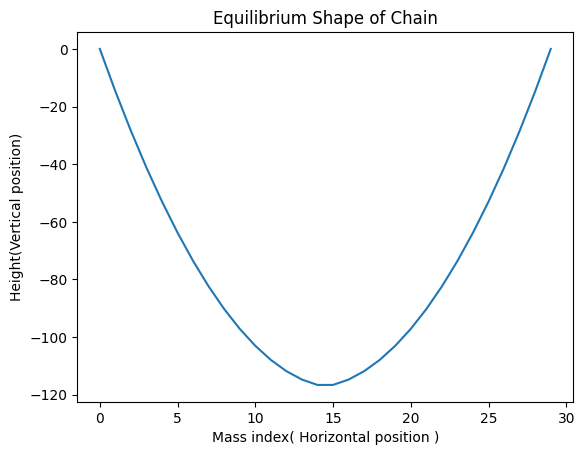

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

N = 30
k = 10
l0 = 1
m = 1
g = 9.8

x = np.arange(N)

# endpoints fixed
y0 = 0
yN = 0

y_initial = np.zeros(N-2)

def energy(y):

    y = np.concatenate(([y0], y, [yN]))

    spring_energy = 0
    for j in range(N-1):
        dy = y[j+1] - y[j]
        length = np.sqrt(1 + dy**2)
        spring_energy += 0.5*k*(length-l0)**2

    grav_energy = np.sum(m*g*y)

    return spring_energy + grav_energy


res = minimize(energy, y_initial)

y_opt = np.concatenate(([y0], res.x, [yN]))

plt.plot(x, y_opt,)
plt.xlabel("Mass index( Horizontal position )")
plt.ylabel("Height(Vertical position)")
plt.title("Equilibrium Shape of Chain")
plt.show()